# 01 - Preparación de Datos

Este notebook cubre las fases CRISP-DM de entendimiento del negocio, entendimiento de datos y preparación. La regla metodológica central es NO usar información de test ni datos sintéticos para seleccionar, escalar o validar modelos.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / 'app').exists() and (ROOT.parent / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.f1_pipeline import (
    CATEGORICAL_FEATURES,
    DEFAULT_SELECTED_FEATURES,
    FeatureEngineer,
    LeakageColumnDropper,
    ColumnSelector,
    Winsorizer,
    smotenc_feature_indices,
)

RANDOM_STATE = 42
SMOTE_SAMPLING_STRATEGY = 0.5  # minority/majority; no iguala clases, limita la minoritaria al 50% de la mayoritaria
DATA_PATH = ROOT / 'f1_final_dataset.csv'
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)
print(f'Root: {ROOT}')

Root: /home/creep/workshop/proyecto-mineria


## Fase 1: Entendimiento del Negocio

### Contexto Fórmula 1
La Fórmula 1 es la máxima categoría del automovilismo internacional. Cada temporada tiene múltiples Grandes Premios donde pilotos y constructores compiten bajo condiciones mecánicas, deportivas y de circuito cambiantes. La predicción de si un piloto terminará una carrera (`finished = 1`) o abandonará (`finished = 0`) es útil para análisis de riesgo deportivo, simulación, estrategia y productos interactivos.

### Problema de Minería de Datos
- **Problema principal:** clasificación binaria de finalización de carrera.
- **Objetivo predictivo:** estimar la probabilidad de terminar la carrera usando solo información disponible antes o al inicio del evento.
- **Restricción metodológica:** `laps` se elimina porque se conoce después de la carrera y produciría leakage directo.

### Diseño de Solución

| Problema | Tipo de minería | Aprendizaje | Métodos | Evaluación |
|---|---|---|---|---|
| ¿El piloto terminará la carrera? | Clasificación predictiva | Supervisado | LR, SVM, KNN, NB, RF, GB, XGBoost, Stacking | Accuracy, Precision, Recall, F1, ROC-AUC |
| ¿Qué variables explican más el riesgo? | Análisis descriptivo | Exploratorio | Correlación, Mutual Information, profiling | Evidencia visual y estadística |

### Criterio de Éxito
Comparar al menos 4 modelos supervisados y 3 ensambles, seleccionar con validación cruzada sobre el 70% original, aplicar ANOVA/Tukey, optimizar los 3 mejores con GridSearchCV, Optuna y algoritmo genético, y desplegar un pipeline que acepte datos crudos pre-carrera.

### Baseline
La clase mayoritaria (`finished = 0`) representa cerca de 74.7% de los registros. Por eso accuracy no basta: un modelo trivial puede acertar mucho sin detectar correctamente la clase minoritaria. La métrica principal de selección será F1, complementada con precision, recall y ROC-AUC.


## Fase 2: Entendimiento de los Datos

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset original: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head())

target_counts = df['finished'].value_counts().sort_index()
target_pct = df['finished'].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({'conteo': target_counts, 'porcentaje': target_pct.round(2)}))

Dataset original: 23,777 filas x 30 columnas


,grid,laps,driver_age,driver_race_count,driver_prev_finish_rate,driver_last5_finish_rate,constructor_race_count,constructor_prev_finish_rate,constructor_prev_avg_grid,constructor_last5_finish_rate,circuit_finish_rate,circuit_avg_grid,race_month,race_day_of_year,season_progress,q1_seconds,q2_seconds,q3_seconds,best_q_time,grid_normalized,has_qualifying,front_row_start,top10_start,year,round,driver_nationality_encoded,constructor_nationality_encoded,circuit_country_encoded,circuitRef_encoded,finished
0,16,13,30.929500,85,0.285714,0.0,1,0.0,0.000000,0.0,0.315900,11.747908,8,217,0.666667,87.609,89.824,88.7805,87.264,0.80,0,0,0,1968,8,29,5,10,45,0
1,5,92,32.301164,37,0.361111,0.0,2,0.0,16.000000,0.0,0.165631,11.685300,10,280,0.916667,87.609,89.824,88.7805,87.264,0.25,0,0,1,1968,11,29,5,31,66,0
2,7,78,34.713210,61,0.383333,0.0,3,0.0,10.500000,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.28,0,0,1,1971,1,29,5,24,33,0
3,11,7,31.036277,8,0.000000,0.0,4,0.0,9.333333,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.44,0,0,0,1971,1,8,5,24,33,0
4,23,5,41.092402,105,0.076923,0.0,5,0.0,9.750000,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.92,0,0,0,1971,1,36,5,24,33,0


,conteo,porcentaje
finished,,
0,17768,74.73
1,6009,25.27


### 2.2 Diccionario de Datos

| Variable | Descripción | Tipo |
|---|---|---|
| `grid` | Posición de salida en parrilla | Numérico |
| `driver_age` | Edad del piloto | Numérico |
| `driver_race_count` | Carreras previas del piloto | Numérico |
| `driver_prev_finish_rate` | Tasa histórica de finalización del piloto | Numérico |
| `driver_last5_finish_rate` | Tasa de finalización en últimas 5 carreras | Numérico |
| `constructor_race_count` | Carreras previas del constructor | Numérico |
| `constructor_prev_finish_rate` | Tasa histórica de finalización del constructor | Numérico |
| `constructor_prev_avg_grid` | Grid promedio histórico del constructor | Numérico |
| `constructor_last5_finish_rate` | Tasa reciente de finalización del constructor | Numérico |
| `circuit_finish_rate` | Tasa histórica de finalización en el circuito | Numérico |
| `circuit_avg_grid` | Grid promedio histórico del circuito | Numérico |
| `q1_seconds`, `q2_seconds`, `q3_seconds` | Tiempos de clasificación | Numérico |
| `has_qualifying` | Indicador de disponibilidad de clasificación | Binario |
| `top10_start` | Indicador de salida en top 10 | Binario |
| `year`, `round` | Contexto temporal de la carrera | Numérico |
| `*_encoded` | Codificaciones categóricas de nacionalidad/circuito | Categórico codificado |
| `finished` | Variable objetivo: 1 terminó, 0 no terminó | Binario |
| `laps` | Vueltas completadas; eliminada por leakage | Numérico post-evento |


### 2.3 Reglas de Calidad desde el Negocio

Antes de modelar se verifican reglas de integridad del dominio:

- `driver_age` debe estar en un rango humano y reglamentario razonable.
- `grid` debe estar dentro de posiciones históricas posibles.
- `finished` solo admite valores 0 y 1.
- Las tasas `*_finish_rate` deben estar entre 0 y 1.
- Los tiempos de clasificación pueden tener valores imputados constantes en años antiguos; se documentan, no se eliminan automáticamente.
- `laps` no se usa para entrenamiento porque se conoce después del resultado.


In [3]:
rate_cols = [c for c in df.columns if 'finish_rate' in c]
quality_rules = {
    'finished_binario': bool(df['finished'].isin([0, 1]).all()),
    'grid_en_rango_0_34': bool(df['grid'].between(0, 34).all()),
    'driver_age_en_rango_17_60': bool(df['driver_age'].between(17, 60).all()),
    'tasas_en_0_1': bool(df[rate_cols].apply(lambda s: s.between(0, 1).all()).all()),
    'sin_nulos': bool(df.isna().sum().sum() == 0),
    'laps_presente_pero_excluida_por_leakage': 'laps' in df.columns,
}
display(pd.Series(quality_rules, name='cumple_regla'))


finished_binario                           True
grid_en_rango_0_34                         True
driver_age_en_rango_17_60                  True
tasas_en_0_1                               True
sin_nulos                                  True
laps_presente_pero_excluida_por_leakage    True
Name: cumple_regla, dtype: bool

### 2.4 Estadísticas Descriptivas por Grupo

Además del resumen global, agrupamos las variables por su significado de negocio. Esto facilita detectar si los patrones vienen del piloto, constructor, circuito, calendario o clasificación.


In [4]:
df_no_target = df.drop(columns=['finished'])
var_groups = {
    'Piloto': ['driver_age', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate'],
    'Constructor': ['constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate'],
    'Circuito': ['circuit_finish_rate', 'circuit_avg_grid'],
    'Calendario': ['race_month', 'race_day_of_year', 'season_progress', 'year', 'round'],
    'Clasificación': ['q1_seconds', 'q2_seconds', 'q3_seconds', 'best_q_time', 'grid', 'grid_normalized', 'has_qualifying', 'front_row_start', 'top10_start'],
    'Codificaciones': ['driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded'],
}
for group, cols in var_groups.items():
    available = [c for c in cols if c in df.columns]
    print('\n' + '=' * 72)
    print(f'Grupo: {group}')
    print('=' * 72)
    display(df[available].describe().T.round(4))



Grupo: Piloto


,count,mean,std,min,25%,50%,75%,max
driver_age,23777.0,30.1748,5.0984,17.4538,26.4641,29.6454,33.3771,53.2621
driver_race_count,23777.0,59.0434,59.4337,1.0000,13.0000,39.0000,86.0000,326.0000
driver_prev_finish_rate,23777.0,0.2157,0.2173,0.0000,0.0000,0.1579,0.3563,1.0000
driver_last5_finish_rate,23777.0,0.2505,0.3056,0.0000,0.0000,0.2000,0.4000,1.0000



Grupo: Constructor


,count,mean,std,min,25%,50%,75%,max
constructor_race_count,23777.0,347.5349,417.1877,1.0,60.0000,187.0000,469.0000,2140.0
constructor_prev_finish_rate,23777.0,0.2208,0.1777,0.0,0.0625,0.2059,0.3548,1.0
constructor_prev_avg_grid,23777.0,10.9735,4.1020,0.0,7.6481,10.5018,13.6674,32.0
constructor_last5_finish_rate,23777.0,0.2516,0.2989,0.0,0.0000,0.2000,0.4000,1.0



Grupo: Circuito


...

,count,mean,std,min,25%,50%,75%,max
race_month,23777.0,6.7598,2.3706,1.0000,5.0000,7.0000,9.0000,12.0
race_day_of_year,23777.0,190.0793,71.9059,1.0000,139.0000,192.0000,250.0000,363.0
season_progress,23777.0,0.5352,0.2871,0.0476,0.2857,0.5333,0.7857,1.0
year,23777.0,1987.6751,17.9722,1950.0000,1975.0000,1989.0000,2003.0000,2017.0
round,23777.0,8.1699,4.7890,1.0000,4.0000,8.0000,12.0000,21.0



Grupo: Clasificación


,count,mean,std,min,25%,50%,75%,max
q1_seconds,23777.0,88.2726,9.1187,65.064,87.6090,87.6090,87.6090,1002.640
q2_seconds,23777.0,89.7959,4.6220,64.316,89.8240,89.8240,89.8240,132.470
q3_seconds,23777.0,88.8376,3.6132,64.251,88.7805,88.7805,88.7805,129.776
best_q_time,23777.0,87.8706,9.0334,64.251,87.2640,87.2640,87.2640,1002.640
grid,23777.0,11.2703,7.3464,0.000,5.0000,11.0000,17.0000,34.000
grid_normalized,23777.0,0.4862,0.3070,0.000,0.2222,0.5000,0.7500,1.000
has_qualifying,23777.0,0.3111,0.4630,0.000,0.0000,0.0000,1.0000,1.000
front_row_start,23777.0,0.1484,0.3555,0.000,0.0000,0.0000,0.0000,1.000
top10_start,23777.0,0.4789,0.4996,0.000,0.0000,0.0000,1.0000,1.000



Grupo: Codificaciones


,count,mean,std,min,25%,50%,75%,max
driver_nationality_encoded,23777.0,15.4850,9.8112,0.0,8.0,17.0,23.0,40.0
constructor_nationality_encoded,23777.0,8.7457,5.1044,0.0,5.0,5.0,14.0,23.0
circuit_country_encoded,23777.0,15.1091,9.3659,0.0,7.0,13.0,24.0,31.0
circuitRef_encoded,23777.0,39.7683,18.8570,0.0,25.0,39.0,59.0,71.0


### 2.5 Distribuciones y Desbalance de la Variable Objetivo

El análisis visual confirma el desbalance de clases y muestra la forma de las variables principales. Esto justifica usar F1 y balanceo controlado solo dentro del entrenamiento.


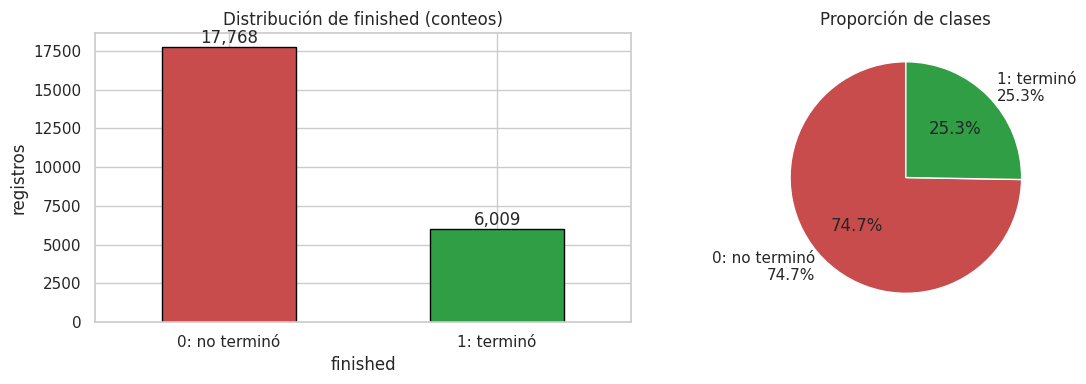

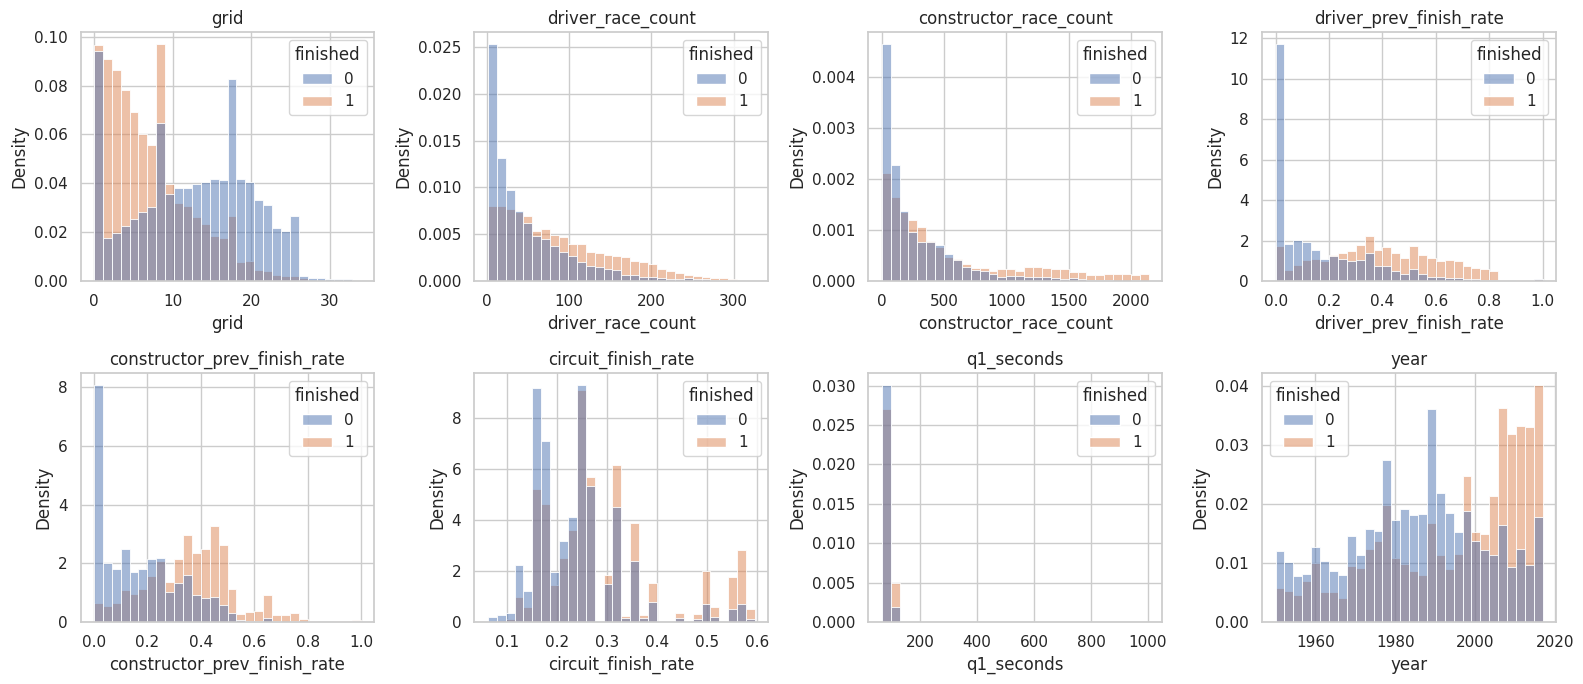

In [5]:
finished_counts = df['finished'].value_counts().sort_index()
finished_pct = df['finished'].value_counts(normalize=True).sort_index().mul(100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
finished_counts.plot(kind='bar', ax=ax[0], color=['#c94c4c', '#2f9e44'], edgecolor='black')
ax[0].set_title('Distribución de finished (conteos)')
ax[0].set_xlabel('finished')
ax[0].set_ylabel('registros')
ax[0].set_xticklabels(['0: no terminó', '1: terminó'], rotation=0)
for idx, value in enumerate(finished_counts):
    ax[0].text(idx, value, f'{value:,}', ha='center', va='bottom')
ax[1].pie(
    finished_counts,
    labels=[f'0: no terminó\n{finished_pct.loc[0]:.1f}%', f'1: terminó\n{finished_pct.loc[1]:.1f}%'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#c94c4c', '#2f9e44'],
)
ax[1].set_title('Proporción de clases')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_finished.png', dpi=140, bbox_inches='tight')
plt.show()

plot_cols = ['grid', 'driver_race_count', 'constructor_race_count', 'driver_prev_finish_rate', 'constructor_prev_finish_rate', 'circuit_finish_rate', 'q1_seconds', 'year']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(data=df, x=col, hue='finished', bins=30, kde=False, stat='density', common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'histogramas_variables_clave.png', dpi=140, bbox_inches='tight')
plt.show()


### 2.6 Perfilamiento con ydata-profiling

Se genera un reporte HTML reproducible con `ydata-profiling`. Este reporte documenta distribuciones, correlaciones, alertas de calidad y posibles interacciones. Si la dependencia no está instalada, el notebook no falla: deja instrucciones explícitas para generarlo localmente.


In [6]:
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title='F1 Dataset - ydata-profiling Report', explorative=True, minimal=False)
    report_path = OUTPUT_DIR / 'ydata_profiling_report.html'
    profile.to_file(report_path)
    print(f'Reporte ydata-profiling guardado en: {report_path}')
except Exception as exc:
    print('No se pudo generar ydata-profiling en este entorno.')
    print(f'Error: {type(exc).__name__}: {exc}')
    print('Validación local sugerida: uv pip install ydata-profiling && ejecutar esta celda.')


No se pudo generar ydata-profiling en este entorno.
Error: ModuleNotFoundError: No module named 'pkg_resources'
Validación local sugerida: uv pip install ydata-profiling && ejecutar esta celda.


### 2.7 Outliers y Valores Imputados

Los boxplots ayudan a identificar variables con colas largas. En este proyecto preferimos winsorización suave sobre eliminación de registros para conservar información histórica.


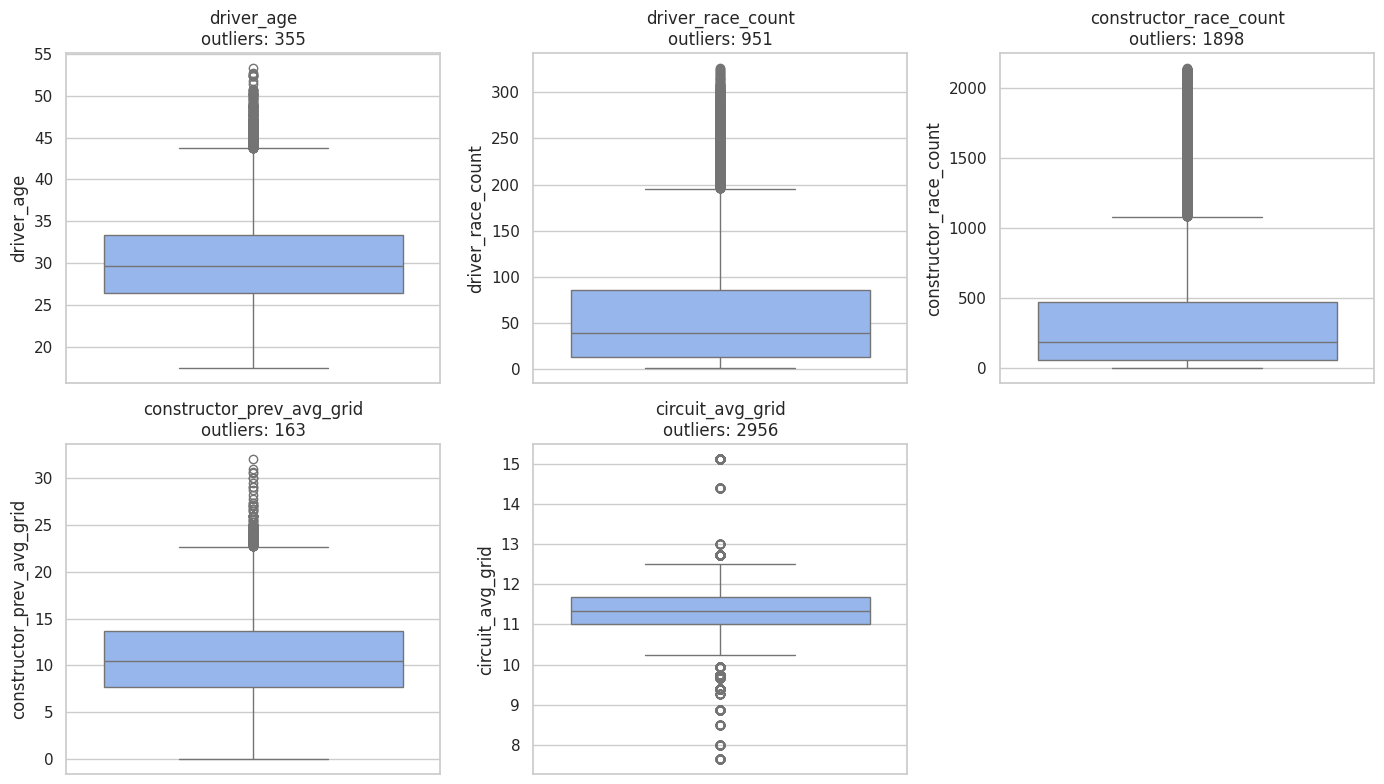

,variable,n_outliers,pct_outliers,lower_bound,upper_bound,accion
0,driver_age,355,1.49,16.094,43.747,winsorización en pipeline
1,driver_race_count,951,4.00,-96.500,195.500,winsorización en pipeline
2,constructor_race_count,1898,7.98,-553.500,1082.500,winsorización en pipeline
3,constructor_prev_avg_grid,163,0.69,-1.381,22.696,winsorización en pipeline
4,circuit_avg_grid,2956,12.43,10.040,12.663,winsorización en pipeline


,variable,valor_mas_frecuente,conteo,pct
0,q1_seconds,87.6090,16382,68.90
1,q2_seconds,89.8240,20127,84.65
2,q3_seconds,88.7805,21599,90.84
3,best_q_time,87.2640,16381,68.89


In [7]:
continuous_vars = ['driver_age', 'driver_race_count', 'constructor_race_count', 'constructor_prev_avg_grid', 'circuit_avg_grid']
outlier_summary = []
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, col in enumerate(continuous_vars):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary.append({
        'variable': col,
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(mask.mean() * 100, 2),
        'lower_bound': round(lower, 3),
        'upper_bound': round(upper, 3),
        'accion': 'winsorización en pipeline' if mask.any() else 'sin acción',
    })
    sns.boxplot(y=df[col], ax=axes[idx], color='#89b4fa')
    axes[idx].set_title(f'{col}\noutliers: {mask.sum()}')
for ax in axes[len(continuous_vars):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'outliers_boxplots.png', dpi=140, bbox_inches='tight')
plt.show()
display(pd.DataFrame(outlier_summary))

qual_cols = ['q1_seconds', 'q2_seconds', 'q3_seconds', 'best_q_time']
qual_summary = []
for col in qual_cols:
    top_value = df[col].value_counts().index[0]
    top_count = df[col].value_counts().iloc[0]
    qual_summary.append({'variable': col, 'valor_mas_frecuente': top_value, 'conteo': top_count, 'pct': round(top_count / len(df) * 100, 2)})
display(pd.DataFrame(qual_summary))


In [8]:
quality = {
    'finished_binario': bool(df['finished'].isin([0, 1]).all()),
    'grid_en_rango_0_34': bool(df['grid'].between(0, 34).all()),
    'driver_age_en_rango_17_60': bool(df['driver_age'].between(17, 60).all()),
    'sin_nulos': bool(df.isna().sum().sum() == 0),
    'laps_presente_pero_excluida_por_leakage': 'laps' in df.columns,
}
display(pd.Series(quality, name='cumple'))

desc = df.describe().T
desc['missing'] = df.isna().sum()
desc['missing_pct'] = df.isna().mean().mul(100)
display(desc[['count', 'missing', 'missing_pct', 'mean', 'std', 'min', '50%', 'max']].round(3))

finished_binario                           True
grid_en_rango_0_34                         True
driver_age_en_rango_17_60                  True
sin_nulos                                  True
laps_presente_pero_excluida_por_leakage    True
Name: cumple, dtype: bool

,count,missing,missing_pct,mean,std,min,50%,max
grid,23777.0,0,0.0,11.270,7.346,0.000,11.000,34.000
laps,23777.0,0,0.0,45.271,30.525,0.000,52.000,200.000
driver_age,23777.0,0,0.0,30.175,5.098,17.454,29.645,53.262
driver_race_count,23777.0,0,0.0,59.043,59.434,1.000,39.000,326.000
driver_prev_finish_rate,23777.0,0,0.0,0.216,0.217,0.000,0.158,1.000
driver_last5_finish_rate,23777.0,0,0.0,0.250,0.306,0.000,0.200,1.000
constructor_race_count,23777.0,0,0.0,347.535,417.188,1.000,187.000,2140.000
constructor_prev_finish_rate,23777.0,0,0.0,0.221,0.178,0.000,0.206,1.000
constructor_prev_avg_grid,23777.0,0,0.0,10.973,4.102,0.000,10.502,32.000
constructor_last5_finish_rate,23777.0,0,0.0,0.252,0.299,0.000,0.200,1.000


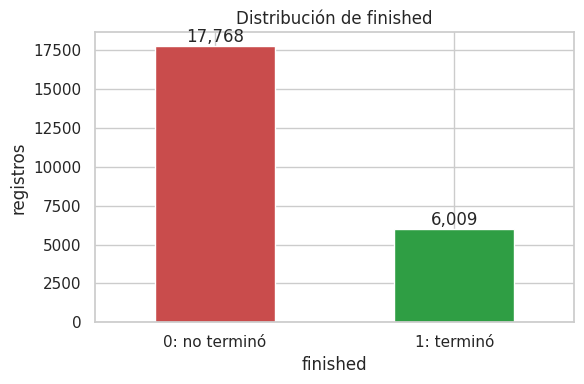

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#c94c4c', '#2f9e44'])
ax.set_title('Distribución de finished')
ax.set_xlabel('finished')
ax.set_ylabel('registros')
ax.set_xticklabels(['0: no terminó', '1: terminó'], rotation=0)
for idx, value in enumerate(target_counts):
    ax.text(idx, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_finished.png', dpi=140, bbox_inches='tight')
plt.show()

## Fase 3: Preparación de Datos

La división train/test se hace ANTES de cualquier selección, winsorización, escalado o balanceo. Las decisiones de selección de variables se justifican con diagnósticos calculados solo sobre el 70% de entrenamiento original.

In [10]:
df_model = df.drop(columns=['laps'])
X = df_model.drop(columns=['finished'])
y = df_model['finished']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print('Split estratificado:')
print(f'Train original: {X_train_raw.shape[0]:,} filas')
print(y_train.value_counts().sort_index().to_dict())
print(f'Test original: {X_test_raw.shape[0]:,} filas')
print(y_test.value_counts().sort_index().to_dict())

Split estratificado:
Train original: 16,643 filas
{0: 12437, 1: 4206}
Test original: 7,134 filas
{0: 5331, 1: 1803}


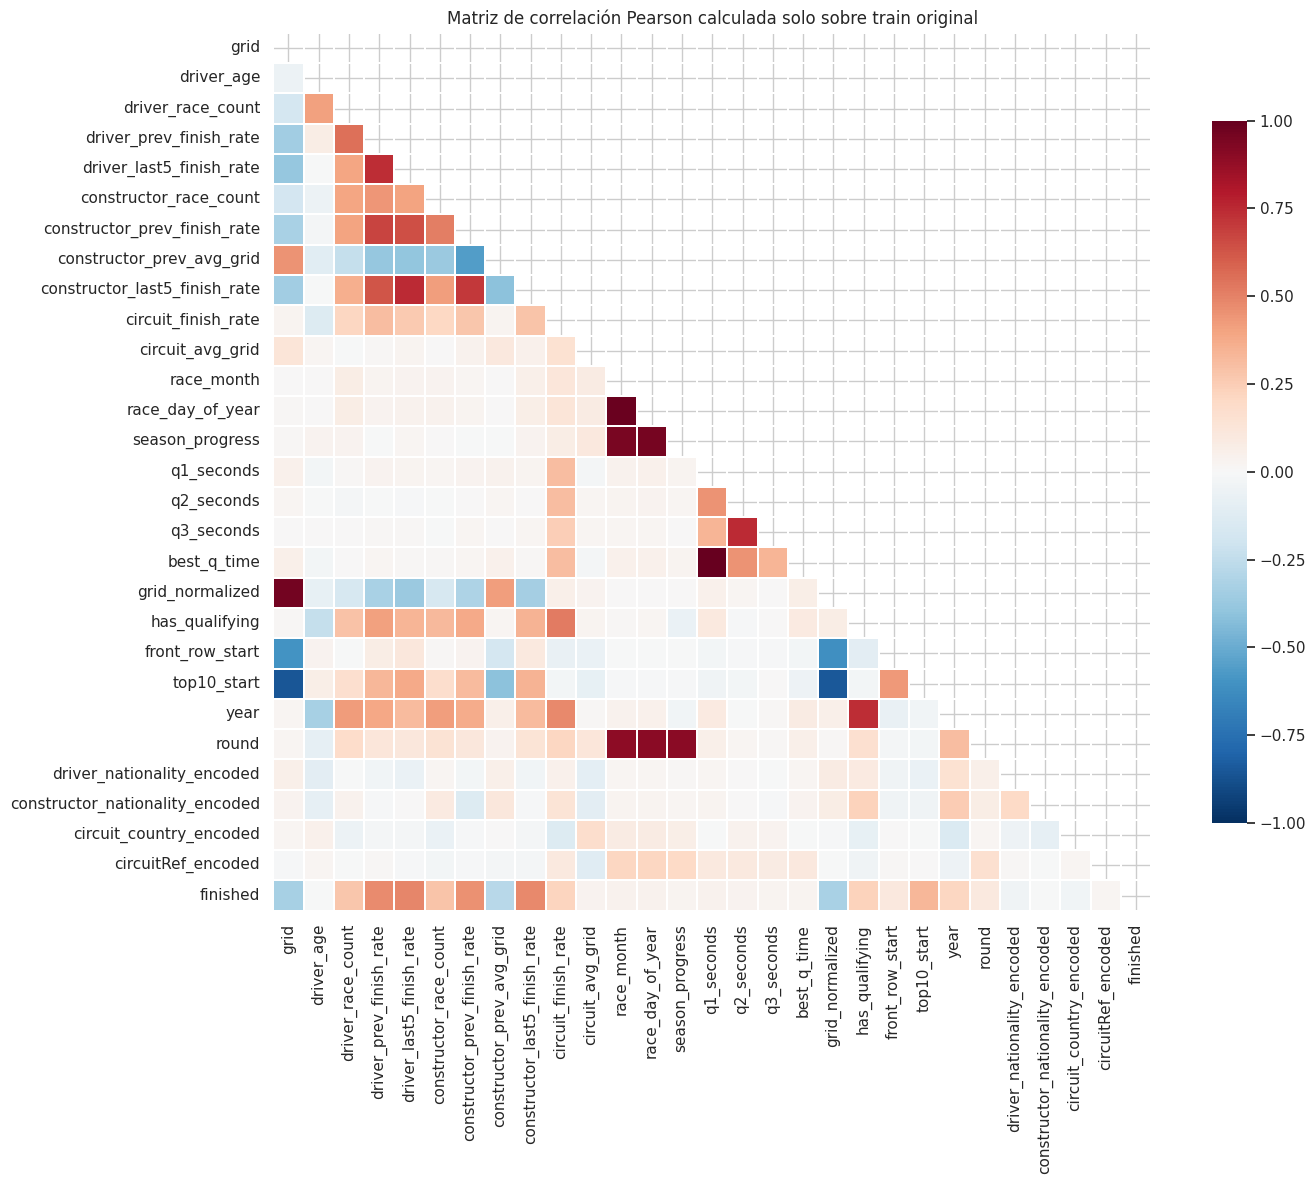

,feature_a,feature_b,corr
8,q1_seconds,best_q_time,0.9959
2,race_month,race_day_of_year,0.9921
0,grid,grid_normalized,0.9670
5,race_day_of_year,season_progress,0.9548
3,race_month,season_progress,0.9514
6,race_day_of_year,round,0.9059
7,season_progress,round,0.9054
4,race_month,round,0.8959
1,grid,top10_start,-0.8516
9,grid_normalized,top10_start,-0.8508


/tmp/ipykernel_2830845/1323879790.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='mutual_information', y='feature', palette=colors)


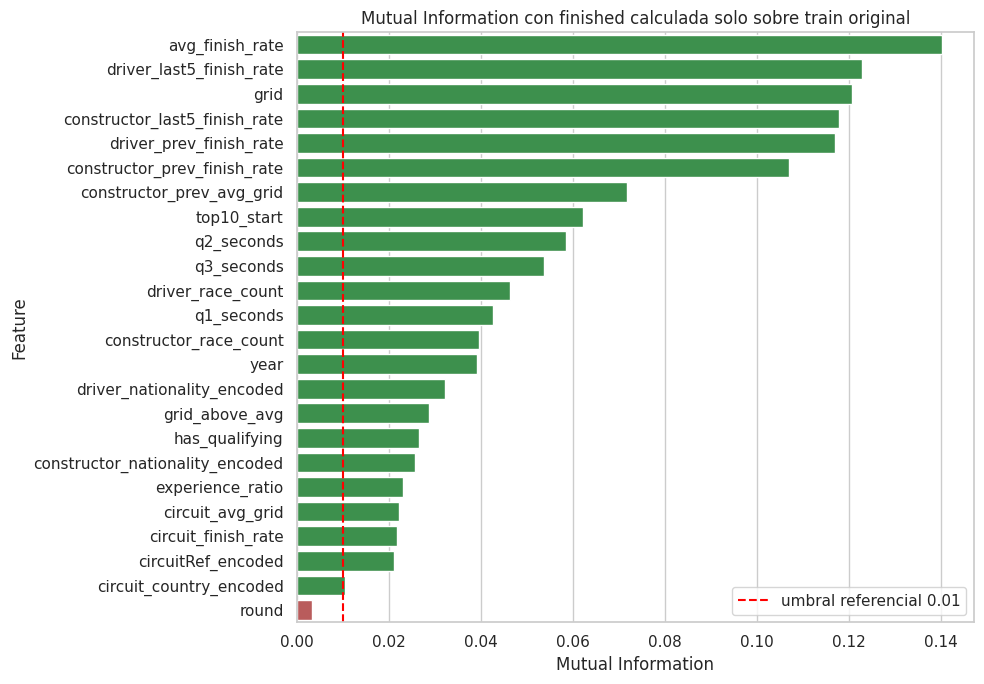

,abs_corr_finished_train
driver_last5_finish_rate,0.4912
constructor_last5_finish_rate,0.4806
driver_prev_finish_rate,0.4692
constructor_prev_finish_rate,0.4559
top10_start,0.3340
grid,0.3289
grid_normalized,0.3245
constructor_race_count,0.2829
constructor_prev_avg_grid,0.2803
driver_race_count,0.2743


,feature,mutual_information
23,avg_finish_rate,0.14011
3,driver_last5_finish_rate,0.12271
0,grid,0.12059
7,constructor_last5_finish_rate,0.11775
2,driver_prev_finish_rate,0.11694
5,constructor_prev_finish_rate,0.10691
6,constructor_prev_avg_grid,0.07164
14,top10_start,0.06220
11,q2_seconds,0.05840
12,q3_seconds,0.05370


In [11]:
# Diagnóstico de correlación y MI SOLO con train original.
train_diag = X_train_raw.copy()
train_diag['finished'] = y_train.values
corr_matrix_train = train_diag.corr(numeric_only=True)
corr_target = corr_matrix_train['finished'].drop('finished').abs().sort_values(ascending=False)

plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix_train, dtype=bool))
sns.heatmap(
    corr_matrix_train,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.35,
    cbar_kws={'shrink': 0.8},
)
plt.title('Matriz de correlación Pearson calculada solo sobre train original')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

# Redundancia alta entre features calculada solo en train.
feature_corr = train_diag.drop(columns=['finished']).corr(numeric_only=True)
high_corr_pairs = []
for i, col_a in enumerate(feature_corr.columns):
    for col_b in feature_corr.columns[i + 1:]:
        r = feature_corr.loc[col_a, col_b]
        if abs(r) > 0.8:
            high_corr_pairs.append({'feature_a': col_a, 'feature_b': col_b, 'corr': r})
high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('corr', key=lambda s: s.abs(), ascending=False)
display(high_corr_df.head(20).round(4))

fe_diag = FeatureEngineer().fit_transform(X_train_raw)
mi_X = fe_diag.drop(columns=[c for c in fe_diag.columns if c not in DEFAULT_SELECTED_FEATURES], errors='ignore')
mi_scores = mutual_info_classif(mi_X, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': mi_X.columns, 'mutual_information': mi_scores}).sort_values('mutual_information', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#2f9e44' if value > 0.01 else '#c94c4c' for value in mi_df['mutual_information']]
sns.barplot(data=mi_df, x='mutual_information', y='feature', palette=colors)
plt.axvline(0.01, color='red', linestyle='--', label='umbral referencial 0.01')
plt.title('Mutual Information con finished calculada solo sobre train original')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mutual_information.png', dpi=140, bbox_inches='tight')
plt.show()

display(pd.DataFrame({'abs_corr_finished_train': corr_target}).head(20).round(4))
display(mi_df.round(5))


In [12]:
selected_features = DEFAULT_SELECTED_FEATURES
removed_features = sorted(set(X_train_raw.columns).union({'experience_ratio', 'grid_above_avg', 'avg_finish_rate'}) - set(selected_features))

print(f'Features seleccionadas ({len(selected_features)}):')
print(selected_features)
print('\nFeatures excluidas por leakage/redundancia/baja utilidad diagnóstica:')
print(removed_features)
print('\nCategóricas para SMOTENC:')
print(CATEGORICAL_FEATURES)

Features seleccionadas (24):
['grid', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate', 'constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate', 'circuit_finish_rate', 'circuit_avg_grid', 'q1_seconds', 'q2_seconds', 'q3_seconds', 'has_qualifying', 'top10_start', 'year', 'round', 'driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded', 'experience_ratio', 'grid_above_avg', 'avg_finish_rate']

Features excluidas por leakage/redundancia/baja utilidad diagnóstica:
['best_q_time', 'driver_age', 'front_row_start', 'grid_normalized', 'race_day_of_year', 'race_month', 'season_progress']

Categóricas para SMOTENC:
['has_qualifying', 'top10_start', 'driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded', 'grid_above_avg']


### 3.4 Justificación de Selección y Eliminación de Variables

Las variables finales se definen por tres criterios combinados:

- **Disponibilidad temporal:** se excluye cualquier variable conocida después de la carrera, especialmente `laps`.
- **Redundancia:** se prefieren variables más interpretables cuando dos columnas codifican casi lo mismo, por ejemplo `grid` frente a `grid_normalized`.
- **Utilidad predictiva:** se revisan correlación con target y Mutual Information calculadas solo sobre el 70% de entrenamiento original.

Las variables derivadas `experience_ratio`, `grid_above_avg` y `avg_finish_rate` no se calculan manualmente antes del split final. Se crean dentro de `FeatureEngineer`, tanto en CV como en despliegue, para mantener reproducibilidad.


In [13]:
prep_no_sampler = Pipeline([
    ('drop_leakage', LeakageColumnDropper()),
    ('feature_engineering', FeatureEngineer()),
    ('winsorizer', Winsorizer()),
    ('selector', ColumnSelector(selected_features)),
    ('scaler', StandardScaler()),
])

prep_for_smote = Pipeline([
    ('drop_leakage', LeakageColumnDropper()),
    ('feature_engineering', FeatureEngineer()),
    ('winsorizer', Winsorizer()),
    ('selector', ColumnSelector(selected_features)),
])

X_train_selected = prep_for_smote.fit_transform(X_train_raw, y_train)
X_test_selected = prep_for_smote.transform(X_test_raw)

sampler = SMOTENC(
    categorical_features=smotenc_feature_indices(selected_features),
    sampling_strategy=SMOTE_SAMPLING_STRATEGY,
    random_state=RANDOM_STATE,
    k_neighbors=5,
)
X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_selected, y_train)

scaler = StandardScaler()
X_train_balanced_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_balanced), columns=selected_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_selected), columns=selected_features
)

train_balanced = X_train_balanced_scaled.copy()
train_balanced['finished'] = y_train_balanced.to_numpy()
test_unbalanced = X_test_scaled.copy()
test_unbalanced['finished'] = y_test.to_numpy()

train_original = X_train_raw.copy()
train_original['finished'] = y_train.to_numpy()
test_original = X_test_raw.copy()
test_original['finished'] = y_test.to_numpy()

train_balanced.to_csv(OUTPUT_DIR / 'train_balanced.csv', index=False)
test_unbalanced.to_csv(OUTPUT_DIR / 'test_unbalanced.csv', index=False)
train_original.to_csv(OUTPUT_DIR / 'train_original.csv', index=False)
test_original.to_csv(OUTPUT_DIR / 'test_unbalanced_raw.csv', index=False)

with open(OUTPUT_DIR / 'preprocessing_pipe.pkl', 'wb') as f:
    pickle.dump(prep_no_sampler, f)

schema = {
    'target': 'finished',
    'leakage_columns_removed': ['laps'],
    'selected_features': selected_features,
    'categorical_features_for_smotenc': CATEGORICAL_FEATURES,
    'smote_sampling_strategy': SMOTE_SAMPLING_STRATEGY,
    'smote_rule': 'La clase minoritaria se sobremuestrea como máximo hasta el 50% de la clase mayoritaria; no se igualan clases.',
    'smotenc_categorical_indices': smotenc_feature_indices(selected_features),
    'cv_rule': 'CV se ejecuta sobre train_original.csv con SMOTENC dentro de cada fold, no sobre train_balanced.csv.',
}
with open(OUTPUT_DIR / 'feature_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print('Artefactos guardados:')
print(f"train_original.csv: {train_original.shape}")
print(f"train_balanced.csv: {train_balanced.shape}; clases {pd.Series(y_train_balanced).value_counts().sort_index().to_dict()}")
print(f"SMOTENC sampling_strategy aplicado: {SMOTE_SAMPLING_STRATEGY}")
print(f"test_unbalanced.csv: {test_unbalanced.shape}; clases {y_test.value_counts().sort_index().to_dict()}")
print('preprocessing_pipe.pkl y feature_schema.json actualizados')

Artefactos guardados:
train_original.csv: (16643, 29)
train_balanced.csv: (18655, 25); clases {0: 12437, 1: 6218}
SMOTENC sampling_strategy aplicado: 0.5
test_unbalanced.csv: (7134, 25); clases {0: 5331, 1: 1803}
preprocessing_pipe.pkl y feature_schema.json actualizados


## Resumen metodológico de preparación

- `laps` se eliminó por ser información posterior a la carrera.
- El split 70/30 se hizo antes de selección, winsorización, escalado y SMOTE.
- `train_balanced.csv` documenta el balanceo exigido sobre el 70%, pero NO se usa para validar modelos.
- `SMOTENC` no iguala clases: la clase minoritaria queda como máximo en el 50% de la clase mayoritaria (`sampling_strategy=0.5`).
- La validación cruzada correcta ocurre en el notebook 02 sobre `train_original.csv`, con `SMOTENC` dentro del pipeline de cada fold.